# Exploring Astronomy Word Associations with Small Language Models

---

## Learning Goals

In this tutorial, you will see how language models and text embeddings can be used to explore semantic associations among astronomy words. By the end of this notebook, you will be able to:

1. Build a small Codenames-style word board using astronomy terms.
2. Use an embedding model to measure semantic similarity between clues and board words.
3. Generate candidate clues for pairs or triples of target words.
4. Measure clue safety by checking whether a clue is also close to an avoided word.
5. Optionally compare embedding-based clues with clues generated by a small open-weight language model.

## Introduction

*Codenames* is a word-association game. A spymaster gives a one-word clue and a number, and the clue should point teammates toward several related target words while avoiding unrelated or dangerous words. For example, the words `DOG` and `CAT` might be linked by the clue `pet 2`.

This notebook adapts that idea to astronomy. Instead of asking whether a model can solve a science problem, we ask a simpler question: **what words does the model consider semantically close?** This gives a compact, visual way to introduce several machine-learning ideas that are useful in astronomy workflows:

1. Text embeddings convert words or phrases into vectors.
2. Cosine similarity measures how close two vectors are.
3. Nearest-neighbor search can suggest candidate semantic links.
4. Failure cases reveal model assumptions and limitations.

This notebook is intentionally small. It is designed as an educational tutorial, not a benchmark of language-model performance.


## Imports

This notebook uses the following packages:

* `numpy` for numerical arrays
* `pandas` for tables
* `matplotlib` for plots
* `scikit-learn` for cosine similarity and a lightweight fallback text-vectorizer
* `sentence-transformers` for optional pretrained semantic embeddings
* `transformers` and `torch` for the optional small language-model extension

If you are running this notebook in a fresh environment, uncomment and run the installation cell below.


In [1]:
# Optional install cell for Colab or a fresh local environment.
# Uncomment if needed.
# %pip install -q numpy pandas matplotlib scikit-learn sentence-transformers transformers accelerate torch


In [2]:
import itertools
import random
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

RANDOM_SEED = 25
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


## 1. Define a tiny Codenames-style board

We begin with a familiar non-astronomy board. This lets us check that the code behaves as expected before moving to astronomy vocabulary.


In [3]:
board = ["DOG", "CAT", "CAR", "TRAIN", "APPLE", "BANANA", "PIANO", "GUITAR"]
clues = ["pet", "vehicle", "fruit", "music", "weather", "emotion"]

pd.DataFrame({"Board Word": board})


,Board Word
0,DOG
1,CAT
2,CAR
3,TRAIN
4,APPLE
5,BANANA
6,PIANO
7,GUITAR


## 2. Load an embedding model

The preferred backend is a small pretrained `sentence-transformers` model. It produces useful semantic vectors for short words and phrases.

To keep the notebook robust in environments without internet access or without `sentence-transformers`, the code also includes a lightweight `TfidfVectorizer` fallback. The fallback is less semantic, but it lets the tutorial run and keeps the helper functions transparent.


In [4]:
class EmbeddingBackend:
    # Small wrapper that provides an .encode(list_of_texts) method.

    def __init__(self, backend="auto", corpus=None):
        self.name = None
        self.model = None
        self.vectorizer = None

        if backend in ("auto", "sentence-transformers"):
            try:
                from sentence_transformers import SentenceTransformer
                self.model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
                self.name = "sentence-transformers/all-MiniLM-L6-v2"
                return
            except Exception as exc:
                if backend == "sentence-transformers":
                    raise exc
                print("sentence-transformers is unavailable; using the local TF-IDF fallback.")

        if corpus is None:
            corpus = []
        self.vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))
        self.vectorizer.fit(list(corpus))
        self.name = "local character TF-IDF fallback"

    def encode(self, texts):
        if isinstance(texts, str):
            texts = [texts]
        if self.model is not None:
            return np.asarray(self.model.encode(texts, normalize_embeddings=True))
        return self.vectorizer.transform(texts).toarray()

corpus_for_fallback = board + clues
embedding_model = EmbeddingBackend(backend="auto", corpus=corpus_for_fallback)
print(f"Embedding backend: {embedding_model.name}")


sentence-transformers is unavailable; using the local TF-IDF fallback.
Embedding backend: local character TF-IDF fallback


## 3. Measure clue-to-word similarity

Cosine similarity ranges from -1 to 1 for dense embeddings. Larger values mean the model places two words closer together in the embedding space. For normalized embeddings, cosine similarity is a convenient nearest-neighbor score.


In [5]:
def similarity_table(board_words, clue_words, embedding_backend):
    # Return a clue-by-board table of cosine similarities.
    board_embeddings = embedding_backend.encode(board_words)
    clue_embeddings = embedding_backend.encode(clue_words)
    sims = cosine_similarity(clue_embeddings, board_embeddings)
    return pd.DataFrame(sims, index=clue_words, columns=board_words)

similarity_df = similarity_table(board, clues, embedding_model)
similarity_df.round(3)


,DOG,CAT,CAR,TRAIN,APPLE,BANANA,PIANO,GUITAR
pet,0.0,0.075,0.000,0.000,0.000,0.0,0.068,0.000
vehicle,0.0,0.000,0.000,0.000,0.133,0.0,0.000,0.000
fruit,0.0,0.058,0.000,0.000,0.000,0.0,0.000,0.149
music,0.0,0.000,0.000,0.000,0.000,0.0,0.000,0.000
weather,0.0,0.060,0.049,0.000,0.000,0.0,0.000,0.033
emotion,0.0,0.000,0.000,0.043,0.000,0.0,0.000,0.000


In [6]:
def top_words_for_clue(clue, board_words, embedding_backend, n=4):
    board_embeddings = embedding_backend.encode(board_words)
    clue_embedding = embedding_backend.encode([clue])
    sims = cosine_similarity(clue_embedding, board_embeddings)[0]
    order = np.argsort(sims)[::-1]
    return pd.DataFrame({
        "Board Word": [board_words[i] for i in order[:n]],
        "Similarity": [sims[i] for i in order[:n]],
    })

top_words_for_clue("vehicle", board, embedding_model, n=4)


,Board Word,Similarity
0,APPLE,0.133145
1,GUITAR,0.000000
2,PIANO,0.000000
3,BANANA,0.000000


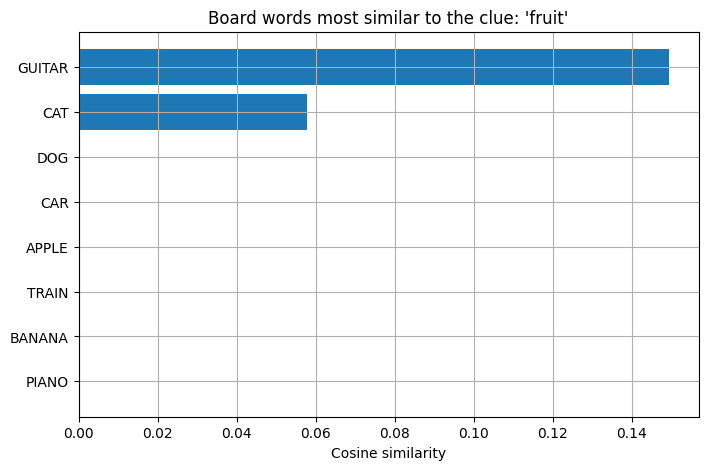

In [7]:
def plot_clue_scores(clue, board_words, embedding_backend):
    df = top_words_for_clue(clue, board_words, embedding_backend, n=len(board_words))
    df = df.sort_values("Similarity")

    plt.figure(figsize=(8, 5))
    plt.barh(df["Board Word"], df["Similarity"])
    plt.xlabel("Cosine similarity")
    plt.title(f"Board words most similar to the clue: '{clue}'")
    plt.show()

plot_clue_scores("fruit", board, embedding_model)


### Interpreting the result

A good clue should be close to the intended target words and less close to unrelated words. In the toy board, clues such as `fruit`, `vehicle`, and `music` should ideally retrieve the matching pairs.

This is not the same as true game-playing. The embedding model does not know whose turn it is, which words are dangerous, or what a human teammate will guess. It only gives a geometric estimate of semantic closeness.


## 4. Compare multiple clues at once

A heat map makes it easier to see which clues activate which parts of the board.


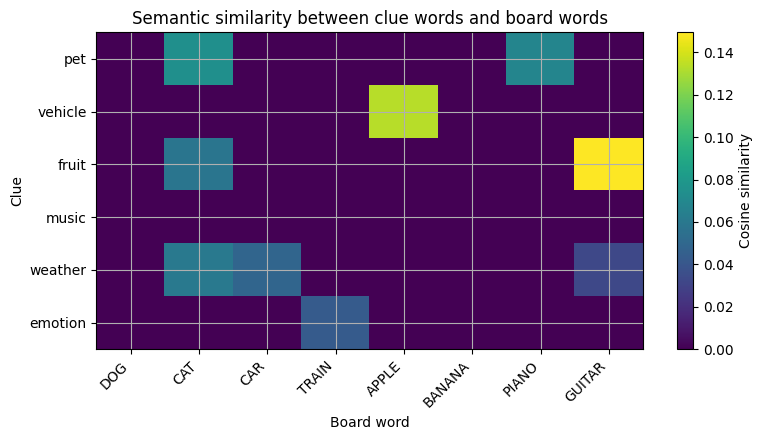

In [8]:
plt.figure(figsize=(8, 4.5))
plt.imshow(similarity_df, aspect="auto")
plt.colorbar(label="Cosine similarity")
plt.xticks(range(len(board)), board, rotation=45, ha="right")
plt.yticks(range(len(clues)), clues)
plt.title("Semantic similarity between clue words and board words")
plt.xlabel("Board word")
plt.ylabel("Clue")
plt.tight_layout()
plt.show()


## 5. Build an astronomy Codenames board

Now we move from the toy example to astronomy vocabulary. The board words include a mixture of objects, instruments, surveys, analysis terms, and publication words. The clue dictionary includes scientific concepts that might connect multiple board words.


In [9]:
board_words = [
    "galaxy", "star", "planet", "nebula", "quasar", "supernova", "black hole", "cluster",
    "redshift", "spectrum", "photometry", "morphology", "metallicity", "stellar mass", "dust", "gas",
    "Hubble", "JWST", "TESS", "Roman", "Gaia", "MAST", "archive", "catalog",
    "image", "light curve", "simulation", "telescope", "detector", "filter", "pixel", "noise",
    "Python", "notebook", "model", "embedding", "classification", "regression", "visualization", "publication"
]

clue_words = [
    "galaxies", "stars", "exoplanets", "transient", "explosion", "accretion", "cosmology",
    "distance", "spectrum", "colors", "shape", "mass", "chemistry", "interstellar", "survey",
    "space", "infrared", "time-series", "astrometry", "archive", "catalog", "data",
    "imaging", "instrument", "wavelength", "calibration", "uncertainty", "simulation",
    "machine-learning", "classification", "regression", "embedding", "visualization", "notebook",
    "tutorial", "research", "paper", "software", "pipeline", "observation"
]

# Reinitialize the fallback corpus with the astronomy vocabulary too. If sentence-transformers loaded,
# this simply keeps the same pretrained model.
embedding_model = EmbeddingBackend(backend="auto", corpus=board + clues + board_words + clue_words)
print(f"Embedding backend: {embedding_model.name}")


sentence-transformers is unavailable; using the local TF-IDF fallback.
Embedding backend: local character TF-IDF fallback


In [10]:
small_board = random.sample(board_words, 12)
small_board


['image',
 'galaxy',
 'stellar mass',
 'Roman',
 'pixel',
 'planet',
 'Hubble',
 'model',
 'classification',
 'TESS',
 'regression',
 'nebula']

## 6. Find candidate clues for a target set

For a candidate clue, we want the target words to be among the most similar board words. The helper function below scores each candidate clue by:

1. the mean similarity to the chosen target words, and
2. a separation margin between the weakest target similarity and the strongest non-target similarity.

The margin is useful because a clue that is equally close to many words may be confusing.


In [11]:
def rank_candidate_clues(board_words, target_words, candidate_clues, embedding_backend, top_k=10):
    # Rank candidate clues for a fixed set of target words.
    board_embeddings = embedding_backend.encode(board_words)
    clue_embeddings = embedding_backend.encode(candidate_clues)
    sims = cosine_similarity(clue_embeddings, board_embeddings)

    target_idx = [board_words.index(w) for w in target_words]
    non_target_idx = [i for i, w in enumerate(board_words) if w not in target_words]

    rows = []
    for clue, scores in zip(candidate_clues, sims):
        target_scores = scores[target_idx]
        non_target_scores = scores[non_target_idx] if non_target_idx else np.array([0.0])
        strongest_non_target = float(np.max(non_target_scores))
        weakest_target = float(np.min(target_scores))
        rows.append({
            "Clue": clue,
            "Targets": ", ".join(target_words),
            "Mean target similarity": float(np.mean(target_scores)),
            "Weakest target similarity": weakest_target,
            "Strongest non-target similarity": strongest_non_target,
            "Separation margin": weakest_target - strongest_non_target,
        })

    ranked = pd.DataFrame(rows)
    ranked = ranked.sort_values(
        ["Separation margin", "Mean target similarity"], ascending=False
    ).reset_index(drop=True)
    return ranked.head(top_k)

example_targets = ["JWST", "Hubble"]
rank_candidate_clues(small_board + example_targets, example_targets, clue_words, embedding_model, top_k=10)


,Clue,Targets,Mean target similarity,Weakest target similarity,Strongest non-target similarity,Separation margin
0,embedding,"JWST, Hubble",0.000000,0.000000,0.000000,0.000000
1,distance,"JWST, Hubble",0.022540,0.018621,0.033003,-0.014382
2,spectrum,"JWST, Hubble",0.000000,0.000000,0.019218,-0.019218
3,uncertainty,"JWST, Hubble",0.000000,0.000000,0.022175,-0.022175
4,archive,"JWST, Hubble",0.010594,0.000000,0.024320,-0.024320
5,chemistry,"JWST, Hubble",0.012462,0.000000,0.025492,-0.025492
6,shape,"JWST, Hubble",0.011636,0.000000,0.026714,-0.026714
7,space,"JWST, Hubble",0.011725,0.000000,0.026918,-0.026918
8,wavelength,"JWST, Hubble",0.012324,0.000000,0.027374,-0.027374
9,survey,"JWST, Hubble",0.000000,0.000000,0.030828,-0.030828


Try changing `example_targets` to another pair, such as `['spectrum', 'redshift']` or `['image', 'pixel']`. The ranking may change depending on whether you use the pretrained embedding backend or the local fallback.


## 7. Search all pairs on a board

A spymaster usually looks for groups of words that can be connected by a single clue. Here we search all pairs on the board and keep the best clue for each pair.


In [12]:
def best_pairwise_clues(board_words, candidate_clues, embedding_backend):
    rows = []
    for word_a, word_b in itertools.combinations(board_words, 2):
        ranked = rank_candidate_clues(
            board_words=board_words,
            target_words=[word_a, word_b],
            candidate_clues=candidate_clues,
            embedding_backend=embedding_backend,
            top_k=1,
        )
        best = ranked.iloc[0]
        rows.append({
            "Word A": word_a,
            "Word B": word_b,
            "Best clue": best["Clue"],
            "Mean target similarity": best["Mean target similarity"],
            "Separation margin": best["Separation margin"],
        })
    return pd.DataFrame(rows).sort_values("Separation margin", ascending=False).reset_index(drop=True)

pairwise_df = best_pairwise_clues(small_board, clue_words, embedding_model)
pairwise_df.head(12)


,Word A,Word B,Best clue,Mean target similarity,Separation margin
0,classification,regression,accretion,0.146500,0.112269
1,stellar mass,TESS,mass,0.399969,0.088866
2,galaxy,TESS,galaxies,0.302089,0.033686
3,galaxy,classification,catalog,0.063279,0.032412
4,pixel,planet,pipeline,0.108590,0.030643
5,classification,nebula,data,0.035335,0.021780
6,image,regression,infrared,0.044038,0.021036
7,galaxy,stellar mass,survey,0.025906,0.020984
8,planet,nebula,exoplanets,0.258659,0.014264
9,stellar mass,regression,software,0.041852,0.013976


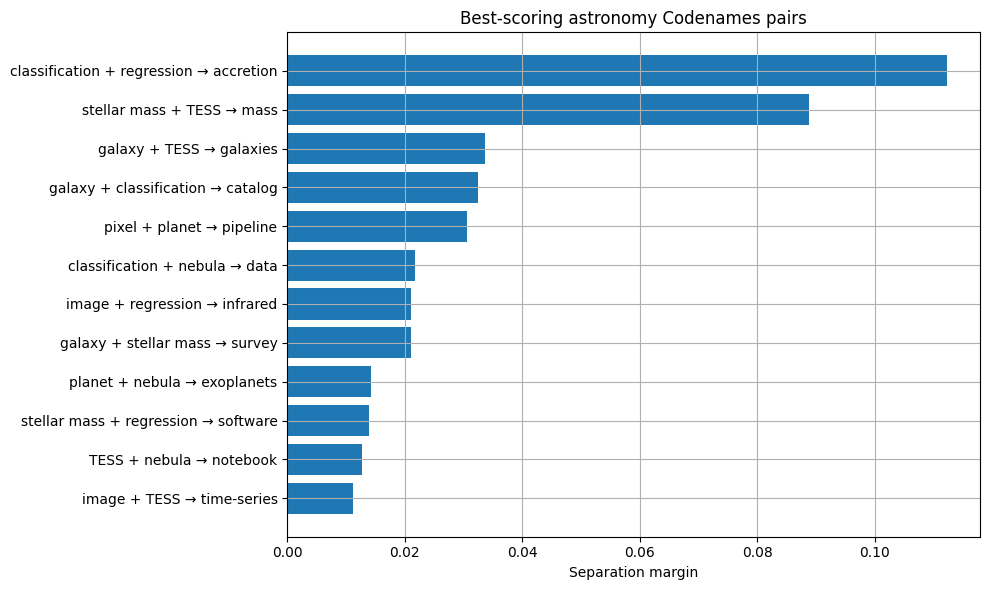

In [13]:
def plot_pairwise_margin(pairwise_df, n=15):
    plot_df = pairwise_df.head(n).copy()
    plot_df["Pair"] = plot_df["Word A"] + " + " + plot_df["Word B"] + " → " + plot_df["Best clue"]
    plot_df = plot_df.sort_values("Separation margin")

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["Pair"], plot_df["Separation margin"])
    plt.xlabel("Separation margin")
    plt.title("Best-scoring astronomy Codenames pairs")
    plt.tight_layout()
    plt.show()

plot_pairwise_margin(pairwise_df, n=12)


### Interpreting pairwise clues

High-margin pairs are easier for the embedding model to separate from the rest of the board. Low-margin pairs are more ambiguous. In a real game, ambiguous clues are risky because teammates may choose an unrelated word that is semantically nearby.


## 8. Avoiding the assassin: semantic risk

In Codenames, one board word is the assassin. If teammates guess it, the team loses. We can mimic this by penalizing clues that are close to an avoided word.

The function below searches for clues that connect two target words while staying far from a specified assassin word.


In [14]:
def best_safe_clues(board_words, target_words, assassin_word, candidate_clues, embedding_backend, top_k=10):
    board_plus = list(dict.fromkeys(board_words + list(target_words) + [assassin_word]))
    base = rank_candidate_clues(board_plus, target_words, candidate_clues, embedding_backend, top_k=len(candidate_clues))

    assassin_embedding = embedding_backend.encode([assassin_word])
    clue_embeddings = embedding_backend.encode(base["Clue"].tolist())
    assassin_scores = cosine_similarity(clue_embeddings, assassin_embedding)[:, 0]

    safe = base.copy()
    safe["Assassin similarity"] = assassin_scores
    safe["Safety-adjusted score"] = safe["Separation margin"] - safe["Assassin similarity"]
    return safe.sort_values("Safety-adjusted score", ascending=False).head(top_k).reset_index(drop=True)

safe_df = best_safe_clues(
    board_words=small_board,
    target_words=["JWST", "Hubble"],
    assassin_word="telescope",
    candidate_clues=clue_words,
    embedding_backend=embedding_model,
    top_k=10,
)
safe_df


,Clue,Targets,Mean target similarity,Weakest target similarity,Strongest non-target similarity,Separation margin,Assassin similarity,Safety-adjusted score
0,embedding,"JWST, Hubble",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,uncertainty,"JWST, Hubble",0.000000,0.000000,0.022175,-0.022175,0.000000,-0.022175
2,chemistry,"JWST, Hubble",0.012462,0.000000,0.025492,-0.025492,0.000000,-0.025492
3,distance,"JWST, Hubble",0.022540,0.018621,0.033003,-0.014382,0.015777,-0.030159
4,survey,"JWST, Hubble",0.000000,0.000000,0.030828,-0.030828,0.000000,-0.030828
5,instrument,"JWST, Hubble",0.024608,0.000000,0.035411,-0.035411,0.000000,-0.035411
6,archive,"JWST, Hubble",0.010594,0.000000,0.024320,-0.024320,0.017951,-0.042271
7,space,"JWST, Hubble",0.011725,0.000000,0.026918,-0.026918,0.019869,-0.046787
8,spectrum,"JWST, Hubble",0.000000,0.000000,0.023976,-0.023976,0.023976,-0.047951
9,data,"JWST, Hubble",0.000000,0.000000,0.048891,-0.048891,0.000000,-0.048891


The safety-adjusted score is deliberately simple. It is not an official game strategy, but it illustrates a general machine-learning idea: a model score often needs to include both a reward term and a risk term.


## 9. Optional extension: ask a small language model for clues

Embeddings score a fixed list of candidate clues. A generative language model can instead propose new clues. This extension uses a small open-weight instruction-tuned model from Hugging Face.

This section is optional because it may require downloading model weights. It will run best on a GPU-enabled notebook environment.


In [15]:
RUN_SMALL_LM_EXTENSION = False  # Change to True if you want to download and run the model.

if RUN_SMALL_LM_EXTENSION:
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer

    model_name = "Qwen/Qwen2.5-0.5B-Instruct"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto" if torch.cuda.is_available() else None,
    )
    if not torch.cuda.is_available():
        model.to("cpu")

    print("Model loaded:", model_name)


In [16]:
def generate_codenames_clue(prompt, max_new_tokens=24):
    if not RUN_SMALL_LM_EXTENSION:
        return "Small language-model extension is disabled. Set RUN_SMALL_LM_EXTENSION = True and rerun the setup cell."

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

prompt = """
You are the spymaster in Codenames.

Board words:
JWST, Hubble, star, spectrum, archive, dust, pixel, quasar

Your team words:
JWST, Hubble

Give exactly one clue word and the number 2.
Do not explain.

Answer format:
clue 2
"""

print(generate_codenames_clue(prompt))


Small language-model extension is disabled. Set RUN_SMALL_LM_EXTENSION = True and rerun the setup cell.


### Comparing generation and embedding search

The language model and embedding model answer different questions:

* The language model generates a likely text continuation.
* The embedding model ranks a fixed list of candidate words by vector similarity.

A generated clue may be creative but hard to control. An embedding-selected clue is easier to inspect, but only if the candidate list contains good clues.


## 10. Exercises

1. Replace the astronomy board with terms from your own research area.
2. Add mission-specific terms such as `Kepler`, `Chandra`, `ALMA`, or `Euclid`.
3. Try three-word target sets instead of pairs.
4. Add a stronger risk penalty for clues close to the assassin.
5. Compare results from `all-MiniLM-L6-v2` with another embedding model.
6. Turn the pairwise search into a small interactive game.


## FAQ

**Is this notebook claiming that language models understand astronomy?**  
No. The notebook studies word associations in embedding space and optional generated text. It is a teaching example, not evidence of scientific reasoning.

**Why use Codenames?**  
Codenames is a compact way to study semantic association, ambiguity, and risk. Those ideas also appear in scientific search, archive discovery, classification labels, and natural-language interfaces to data.

**Why include a fallback embedding method?**  
The fallback makes the notebook executable even in restricted environments. For real semantic analysis, use the pretrained sentence-transformer backend.

**Can this be connected to MAST data?**  
Yes. One extension would be to build board words from astronomical object classes, mission names, filters, or metadata fields found in MAST or High-Level Science Product documentation.


## About this Notebook

Author: Shashwat Sourav  
Co-author: [Add second author name]  
Affiliations: Washington University in St. Louis; Oak Ridge National Laboratory; Lawrence Berkeley National Laboratory; [add/update as appropriate]

Info: This notebook was adapted from a prototype notebook on astronomy-themed Codenames and reorganized into the tutorial style used by the Hello Universe notebook collection. The goal is to provide a short, accessible machine-learning tutorial for semantic similarity, prompt sensitivity, and language-model failure modes.

Created: 2026-06-01


## Citations

If you use this notebook or build on it for a project, please cite the software and model resources that you use. Useful references include:

* Reimers, N. & Gurevych, I. (2019). *Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks.* arXiv:1908.10084.
* Wolf, T. et al. (2020). *Transformers: State-of-the-Art Natural Language Processing.* EMNLP: System Demonstrations.
* Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python.* Journal of Machine Learning Research.
* Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment.* Computing in Science & Engineering.
* Harris, C. R. et al. (2020). *Array programming with NumPy.* Nature.
* The Qwen model family documentation and model card, if you run the optional language-model extension.
* The Hello Universe and MAST pages for the notebook collection and archive context.
